# WELCOME TO BAYMAX

## ALL THE IMPORTANT DEPENDENCIES

In [63]:
import csv
import random
import pandas as pd
import os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,classification_report,confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
import tabulate
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout
from IPython.display import display
from PIL import Image
from ipywidgets import widgets

## Description of Models </br>

### First Module <b>Diagnosis Module</b> :

It employs Artificial Neural Network (ANN) that uses symptoms and their corresponding diagnosed disease provided in 'Training.csv'. It then learns the patterns among different symptoms and uses the learned weights to predict the disease based upon the symptoms provided by user. 

* It has 3 feed forward layers
* It employs 2 dropout layers with certain probabilities to prevent overfitting
* The module also exhibits graphs for learning curves to exhibit the progress of ANN

### Second Module <b>Severity Prediction</b> :

It employs a Linear Regression Model (LR). The severity column is calculated prior to training </br> 
given by the formula : <b>Summation(weight_of_found_symptoms)*Disease_severity</b></br>
Severity of disease prepared based on expert's opinion</br>
It uses dataset 'Symptom-Severity.csv'

* LR learns weight of each feature from the given dataset 
* It then uses these weights to predict severity of module 
* Boxplot is then used to display the dispersion of severity values 
* A polar Bar graph has been used to visualize importance of each feature in severity calculation 

### Third Module <b>Prescription For the Patient</b>:

It will employ a Genetic Algorithm that will combine Datasets of 'description.csv','diets.csv','medications.csv','precautions_df.csv' and 'workout_df.csv' as genes of chromosomes and then suggest to a patient best combination of all these perscriptions. 

## Description of Dataset

The dataset for model training has been downloaded from Kaggle</br>
Source link :  </br>
</br>
This dataset records a multitude (132) sympotms seen in patients and also maps them to the diseases that were identified for occurrence of certain pattern of symptoms.</br>
Moreover this dataset provides us with the following information :</br> 
+ Maps Symptoms -> Diseases
+ Maps Diseases -> Medication
+ Maps Diseases -> Workout Suggested
+ Maps Diseases -> Precautionary Habbits suggested to be adopted
+ Maps Diseases -> Diet suggested 
+ Maps Diseases -> Disease's description in detail for user's comprehensibility


### LOADING DATASETS

In [ ]:
file_path = []
file_path.append(os.path.join('Data','gem','description.csv'))
file_path.append(os.path.join('Data','gem','diets.csv'))
file_path.append(os.path.join('Data','gem','medications.csv'))
file_path.append(os.path.join('Data','gem','precautions_df.csv'))
file_path.append(os.path.join('Data','gem','workout_df.csv'))
file_path.append(os.path.join('Data','gem','Training.csv'))
file_path.append(os.path.join('Data','gem','symtoms_df.csv'))
file_path.append(os.path.join('Data','gem','Symptom-severity.csv'))
file_path.append(os.path.join('Data','ahem','train','NORMAL'))
file_path.append(os.path.join('Data','ahem','train','PNEUMONIA'))
file_path.append(os.path.join('Data','ahem','test','NORMAL'))
file_path.append(os.path.join('Data','ahem','test','PNEUMONIA'))
file_path.append(os.path.join('Data','ahem','val','NORMAL'))
file_path.append(os.path.join('Data','ahem','val','PNEUMONIA'))

DATASET = []

for i in file_path:
    with open(i,mode = 'r') as file:
        data = pd.read_csv(file)
        DATASET.append(data)



In [41]:
#setting up model for cnn_pneumonia
ISIZE = (150,150)
BATCH = 32

training_gen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    shear_range=0.1
)

value_gen = ImageDataGenerator(
    rescale = 1./255
    )
test_gen = ImageDataGenerator(
    rescale = 1./255
)

In [3]:


unique = DATASET[5].drop_duplicates().copy()
duplicated = DATASET[5][DATASET[5].duplicated()].copy()


def mutate(duplicated):
    mutation_rate = 0.02
    columns = duplicated.columns[:-1] # removing prognosis
    
    for i in range(len(duplicated)):
        
        for j in range(len(columns)):
            
            if random.random() < mutation_rate:
                
                duplicated.iat[i ,j] = 1 - duplicated.iat[i ,j]
                
    return duplicated


mutated_df = mutate(duplicated)

print("After mutation duplicates:", mutated_df.duplicated().sum())
    
final_dataset = pd.concat([unique, mutated_df], ignore_index=True)
DATASET[5] = final_dataset
print("final dataset len:", len(final_dataset))
print("final dataset duplicates:", final_dataset.duplicated().sum())


After mutation duplicates: 220
final dataset len: 4920
final dataset duplicates: 382


## Meta-Data

In [4]:
for i in range(len(DATASET)):
    print(f"\033[91mDataset {i+1}:\033[0m")
    print(DATASET[i].info())
    print(f'Shape of dataset : {DATASET[i].shape}')
    print(f'Number of rows: {len(DATASET[i])}')
    print(f'Number of columns: {len(DATASET[i].columns)}')
    print(f'Number of Nulls : {DATASET[i].isnull().sum().sum()}')
    print("\033[91m===========================================\033[0m\n")

Dataset 1:
<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Disease      41 non-null     str  
 1   Description  41 non-null     str  
dtypes: str(2)
memory usage: 788.0 bytes
None
Shape of dataset : (41, 2)
Number of rows: 41
Number of columns: 2
Number of Nulls : 0

Dataset 2:
<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Disease  41 non-null     str  
 1   Diet     41 non-null     str  
dtypes: str(2)
memory usage: 788.0 bytes
None
Shape of dataset : (41, 2)
Number of rows: 41
Number of columns: 2
Number of Nulls : 0

Dataset 3:
<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Disease     41 non-null     str  
 1   

## Pre Processing

In [5]:
DATASET[5].drop('fluid_overload.1',axis =1,inplace = True)
print('fluid_overload.1' in DATASET[5].columns)


False


In [6]:
# encoding label part 
# using label encoding 
le = LabelEncoder()
DATASET[5]['prognosis'] = le.fit_transform(DATASET[5]['prognosis'])
print(DATASET[5]['prognosis'])

0       15
1       15
2       15
3       15
4       15
        ..
4915     0
4916     2
4917    38
4918    35
4919    27
Name: prognosis, Length: 4920, dtype: int64


In [7]:
for i in range(len(DATASET)):
    DATASET[i].columns = DATASET[i].columns.str.strip()
    DATASET[i] = DATASET[i].apply(lambda col: col.str.strip() if col.dtype == 'object' else col)


## Visualizations

In [8]:
# Most common symptoms:

symptom_cols = list(DATASET[5].columns[:-1])
symptom_freq = DATASET[5][symptom_cols].sum()
print(symptom_freq)
symptom_freq = symptom_freq.sort_values(ascending=False)

fig = px.bar(x=symptom_cols[:26],y=symptom_freq[:26],labels={'x':'Symptoms','y':'Frequency'},title='Frequency of Symptoms in Training Dataset',color =symptom_cols[:26])
fig.show()

itching                 744
skin_rash               843
nodal_skin_eruptions    191
continuous_sneezing     312
shivering               194
                       ... 
small_dents_in_nails    217
inflammatory_nails      202
blister                 188
red_sore_around_nose    202
yellow_crust_ooze       193
Length: 131, dtype: int64


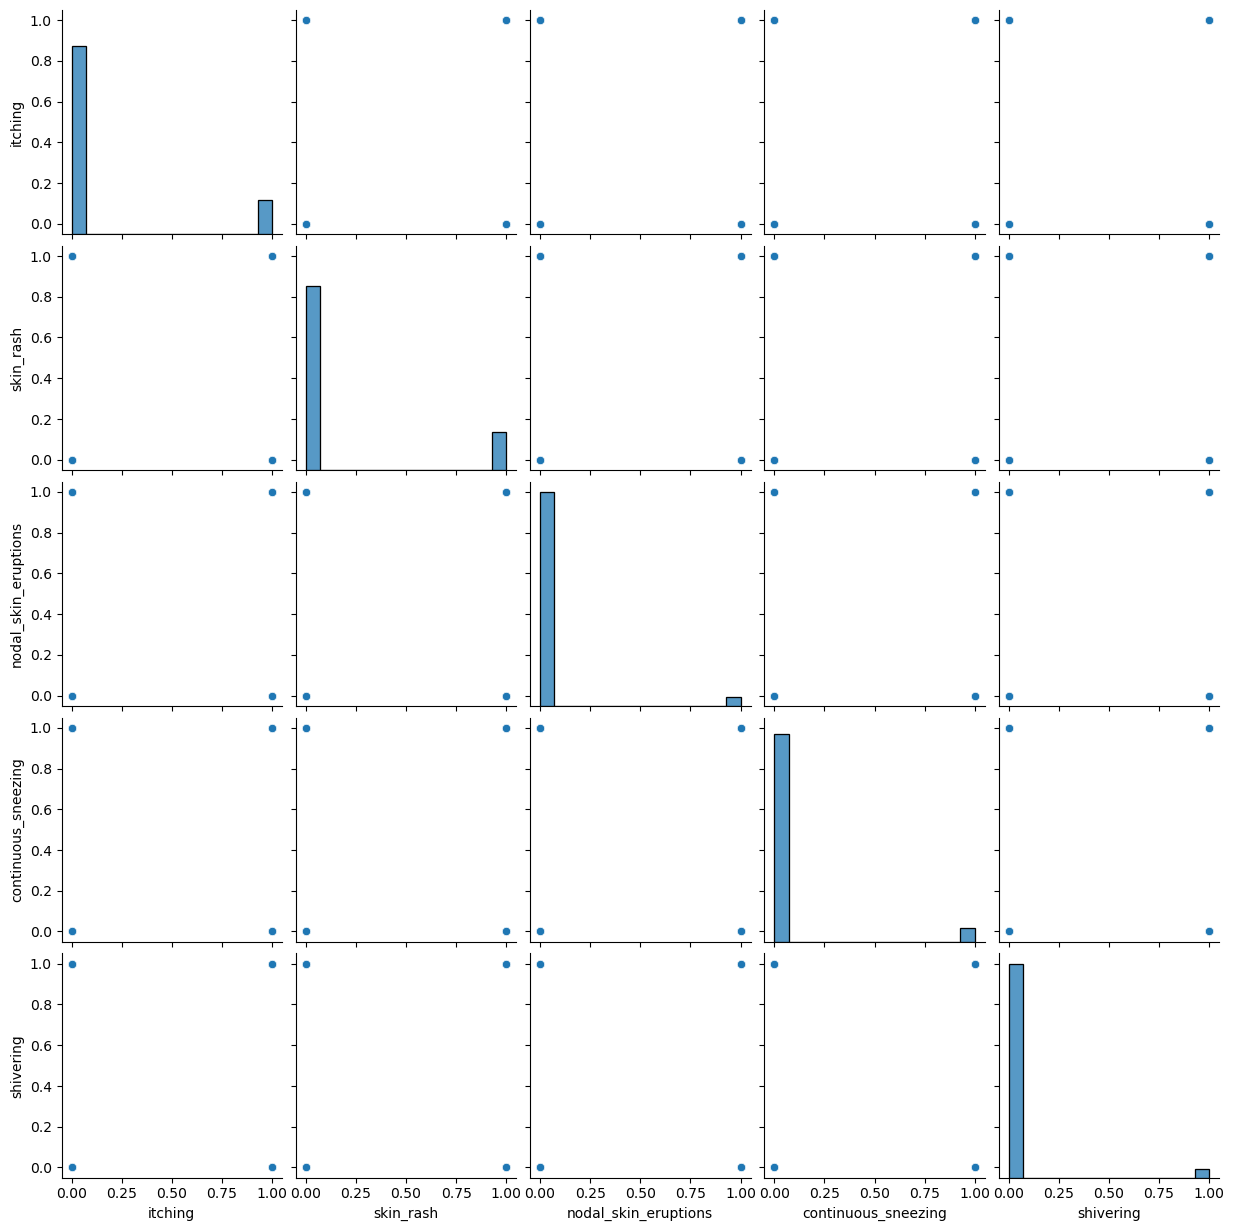

In [9]:
# pair plot between features
# limited to certain features to reduce process time of pairplot (its time complexity is N^2 which can take atleast 20 minutes for our dataset)
sns.pairplot(DATASET[5],vars=DATASET[5].columns[:5])
plt.show()

<AxesSubplot: >

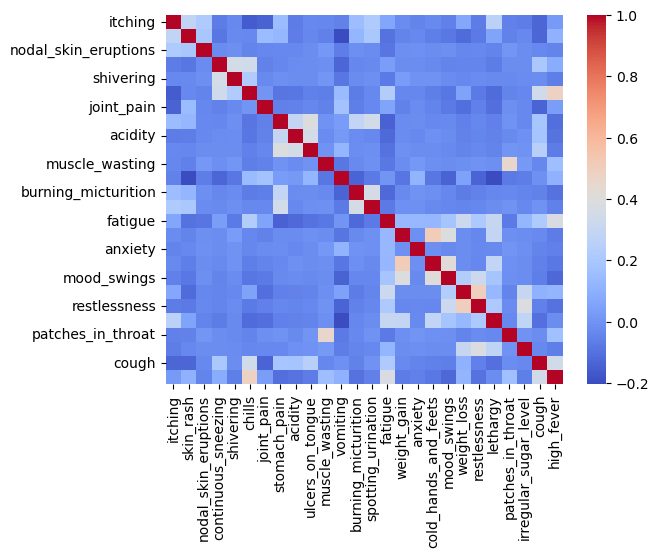

In [10]:
# Correlation between symptoms (which symptoms appear together)
# picking the top 26 symptoms for clarity of heatmap
corr = DATASET[5][symptom_cols[:26]].corr()
sns.heatmap(corr,cmap = 'coolwarm')

## Expert-View On Disease Severity

In [11]:
Disease_severity = {
    'Drug Reaction' : 0.52,
    'Malaria' : 0.72,
    'Allergy' : 0.20,
    'Hypothyroidism' : 0.45, 
    'Psoriasis' : 0.18, 
    'GERD' : 0.35, 
    'Chronic cholestasis' : 0.63, 
    'hepatitis A' : 0.65, 
    'Osteoarthristis' : 0.35, 
    '(vertigo) Paroymsal  Positional Vertigo' : 0.28, 
    'Hypoglycemia' : 0.58, 
    'Acne' : 0.05, 
    'Diabetes' : 0.60, 
    'Impetigo' : 0.15, 
    'Hypertension' : 0.48, 
    'Peptic ulcer diseae' : 0.48, 
    'Dimorphic hemmorhoids(piles)' : 0.42, 
    'Common Cold' : 0.08, 
    'Chicken pox' : 0.25, 
    'Cervical spondylosis' : 0.38, 
    'Hyperthyroidism' : 0.50, 
    'Urinary tract infection' : 0.38, 
    'Varicose veins' : 0.32, 
    'AIDS' : 0.90, 
    'Paralysis (brain hemorrhage)' : 0.95, 
    'Typhoid' : 0.65, 
    'Hepatitis B' : 0.78, 
    'Fungal infection' : 0.12, 
    'Hepatitis C' : 0.30, 
    'Migraine' : 0.55, 
    'Bronchial Asthma' : 0.80, 
    'Alcoholic hepatitis' : 0.90, 
    'Jaundice' : 0.60, 
    'Hepatitis E' : 0.70, 
    'Dengue' : 0.68, 
    'Hepatitis D' : 0.76, 
    'Heart attack' : 1.00, 
    'Pneumonia' : 0.63, 
    'Arthritis' : 0.40, 
    'Gastroenteritis' : 0.40,
    'Tuberculosis': 0.82
}

## Calculating Severity for each row in our Dataset

In [100]:
# preparing dataframe for linear regression:
y = []
disease_col = DATASET[5]['prognosis'].copy()
for index,row in DATASET[5].iterrows():
    total = 0
    for col in DATASET[5].columns[:-1]:
        if row[col] == 1:
            total += DATASET[7][DATASET[7]['Symptom'] == col]['weight'].values[0]

    disease_diagnosed = le.inverse_transform([row[DATASET[5].columns[-1]]])
    total = total*Disease_severity[disease_diagnosed[0]]
    y.append(total)

## Severity Box-Plot

Mean : 21.36	Min : 0.3	Max : 82.82
Standard Deviation : 14.51	Range : 82.52



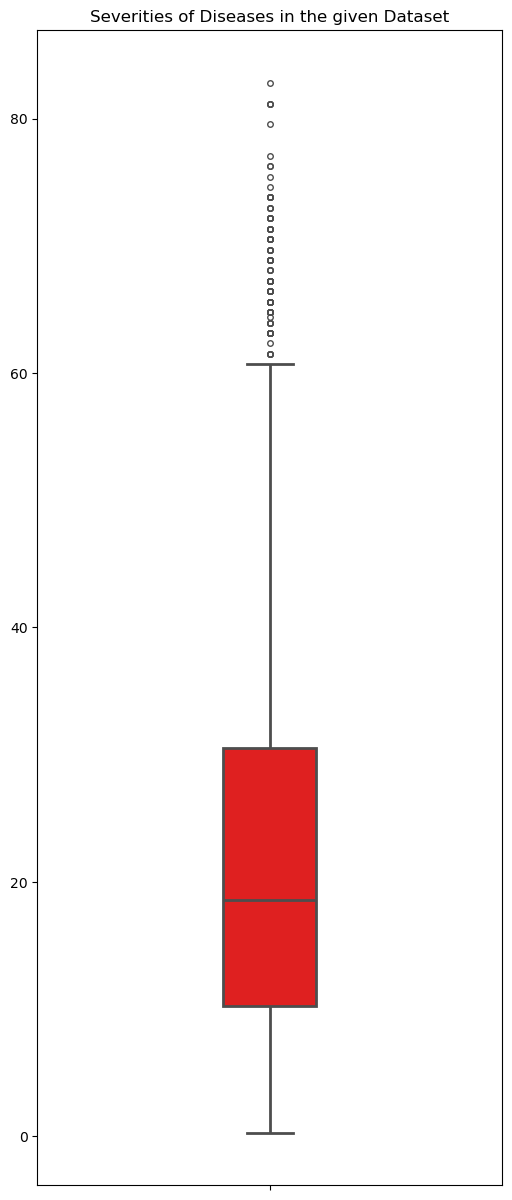

In [102]:
result = np.array(y)
print(f'Mean : {round(result.mean(),2)}\tMin : {round(result.min(),2)}\tMax : {round(result.max(),2)}\nStandard Deviation : {round(result.std(),2)}\tRange : {round(result.max(),2)-round(result.min(),2)}\n')
plt.figure(figsize=(6,15))
sns.boxplot(y=y,width = 0.2,color= "red",linewidth= 2,fliersize=4)
plt.title("Severities of Diseases in the given Dataset")
plt.show()

## LINEAR REGRESSION (SEVERITY MODULE)

In [101]:
# splitting data first for test and train

X = DATASET[5]
y = y.copy()

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr_model = LinearRegression()

lr_model.fit(X_train,y_train)

pred_y = lr_model.predict(X_test)

print(f'\033[91mmean_squared_error : {mean_squared_error(y_test,pred_y)}\033[0m')
print(f'\033[92mR^2 score : {r2_score(y_test,pred_y)}\033[0m')

mean_squared_error : 19.570534349727346
R^2 score : 0.9102734869920263


In [15]:
weights = pd.Series(model.coef_,index=DATASET[5].columns)
weights.sort_values(ascending=False)
px.bar(x=weights[:],title='Importance of Each weight in Calbculating Severity',color = DATASET[5].columns[:])

In [103]:
def Predict_Severity_of_Disease(Symptoms):
    pred_y = lr_model.predict(Symptoms)
    status = ''
    if pred_y > result.mean()+10:
        status = '\033[91mHIGH\033[0m'
    elif pred_y < result.mean():
        status = '\033[92mLow\033[0m'
    else:
        status = '\033[93mMedium\033[0m'
    return (pred_y[0],status)

In [111]:
#testing LR
x,y = Predict_Severity_of_Disease(get_symptoms(['itching','chills','vomiting']))
print(f'severity = {x} ==> {y}')

severity = 25.69254978861263 ==> Medium


## ARTIFICAL NEURAL NETWORK (DIAGNOSIS MODULE)

In [20]:
X = final_dataset.drop(columns=['prognosis'])
print(X.columns)

Y = final_dataset['prognosis']
encoder = LabelEncoder()
Y = encoder.fit_transform(Y)


X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

print(f"\nX_train shape: {X_train.shape} (Training on {X_train.shape[0]} patients, {X_train.shape[1]} symptoms each)")
print(f"y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape} (test set of {X_test.shape[0]} patients)")
print(f"y_test shape: {Y_train.shape}")

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'pus_filled_pimples', 'blackheads', 'scurring', 'skin_peeling',
       'silver_like_dusting', 'small_dents_in_nails', 'inflammatory_nails',
       'blister', 'red_sore_around_nose', 'yellow_crust_ooze'],
      dtype='str', length=131)

X_train shape: (3936, 131) (Training on 3936 patients, 131 symptoms each)
y_train shape: (3936,)
X_test shape: (984, 131) (test set of 984 patients)
y_test shape: (3936,)


In [21]:
baymax_tf_model = Sequential()

baymax_tf_model.add(Dense(units=64, activation='relu', input_shape=(131,))) # input 131 (symptoms) first hidden layer 64 neurons

baymax_tf_model.add(Dropout(0.2)) # Kill 30% chromosomes for better learning 

baymax_tf_model.add(Dense(units=32, activation='relu')) #second hidden layer with 32 neurons

baymax_tf_model.add(Dropout(0.4))

baymax_tf_model.add(Dense(units=41, activation='softmax')) # output layer with softmax acitvation

baymax_tf_model.summary()

baymax_tf_model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history = baymax_tf_model.fit(
    X_train, 
    Y_train,
    epochs=50,            
    batch_size=32,        
    validation_data=(X_test,Y_test), 
    verbose=1             
)




/home/crazymonkey/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778409038.348790    6771 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,881 (46.41 KB)

 Trainable params: 11,881 (46.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1552 - loss: 3.3809 - val_accuracy: 0.6311 - val_loss: 2.6190
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5099 - loss: 2.0673 - val_accuracy: 0.9502 - val_loss: 0.9318
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6999 - loss: 1.1930 - val_accuracy: 0.9868 - val_loss: 0.3666
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7919 - loss: 0.8002 - val_accuracy: 0.9898 - val_loss: 0.1819
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8265 - loss: 0.6397 - val_accuracy: 0.9919 - val_loss: 0.1091
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8605 - loss: 0.5128 - val_accuracy: 0.9909 - val_loss: 0.0712
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8692 - loss: 0.4669 - val_accuracy: 0.9919 - val_loss: 0.0556
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8857 - loss: 0.4047 - val_accuracy: 0

In [22]:
def RunDiagnosis(Symptoms):
    probabilities = baymax_tf_model.predict(Symptoms,verbose=0)[0]
    top_probs = np.argsort(probabilities)[::-1][:3]
    top_disease_names = le.inverse_transform(top_probs)
    top3_diseases_confidentiality_score = probabilities[top_probs]
    return top_disease_names,top3_diseases_confidentiality_score



## visualizing the ann 

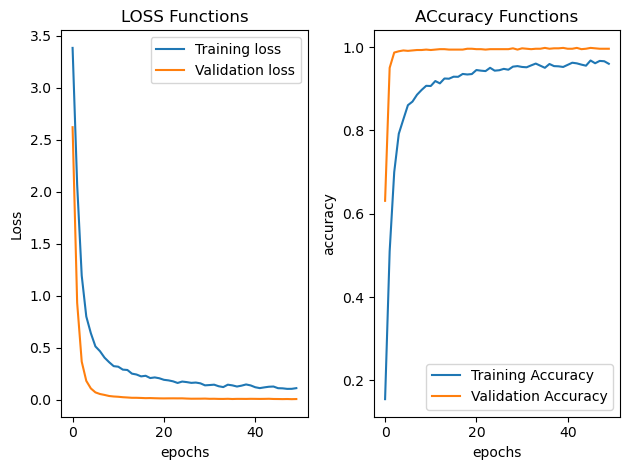

In [23]:


train_loss = history.history['loss']
val_loss = history.history['val_loss']
val_acc = history.history['val_accuracy']
train_acc = history.history['accuracy']

plt.subplot(1,2,1)
plt.plot(train_loss,label='Training loss')
plt.plot(val_loss,label='Validation loss')
plt.title("LOSS Functions")
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1,2,2)
plt.plot(train_acc,label='Training Accuracy')
plt.plot(val_acc,label='Validation Accuracy')
plt.title("ACcuracy Functions")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.tight_layout(


)
plt.show()




In [24]:
Y_pred_probs = baymax_tf_model.predict(X_test, verbose=0)
Y_pred       = np.argmax(Y_pred_probs, axis=1)
Y_pred_names = encoder.inverse_transform(Y_pred)
Y_true_names = encoder.inverse_transform(Y_test)
print(f'Accuracy Score of Our Baymax is : {round(accuracy_score(Y_pred_names,Y_true_names)*100,2)}%')
print(f'classification report: \n {classification_report(Y_true_names,Y_pred_names)}')
print(f'CONFUSION MATRIX__________________________________\n{confusion_matrix(Y_true_names,Y_pred_names)}')

Accuracy Score of Our Baymax is : 99.59%
classification report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       0.96      0.96      0.96        24
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        24
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        24
           9       1.00      0.92      0.96        24
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        24
          16   

## Building CNN for Pneumonia

In [ ]:
training_data = training_gen.flow_from_directory(
    'Data/ahem/train',
    target_size = ISIZE,
    batch_size = BATCH,
    class_mode = 'binary',
    color_mode = 'grayscale'
)

validation_data = value_gen.flow_from_directory(
    'Data/ahem/val',
    target_size = ISIZE,
    batch_size = BATCH,
    class_mode = 'binary',
    color_mode = 'grayscale'
)

test_data = test_gen.flow_from_directory(
    'Data/ahem/test',
    target_size = ISIZE,
    batch_size = BATCH,
    class_mode = 'binary',
    color_mode = 'grayscale'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
{'NORMAL': 0, 'PNEUMONIA': 1}


In [46]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape = (150,150,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),   

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    #output layer
    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics = ['accuracy']
)

model.summary()

history2 = model.fit(
    training_data,
    epochs = 20,
    validation_data = validation_data
)

/home/crazymonkey/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,801 (18.42 MB)

 Trainable params: 4,828,353 (18.42 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20


I0000 00:00:1778412686.318335    6771 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


163/163 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.8829 - loss: 0.5112 - val_accuracy: 0.5000 - val_loss: 6.4393
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.9076 - loss: 0.2399 - val_accuracy: 0.5000 - val_loss: 20.0737
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.9277 - loss: 0.2008 - val_accuracy: 0.5000 - val_loss: 3.9603
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.9383 - loss: 0.1923 - val_accuracy: 0.7500 - val_loss: 0.6237
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.9406 - loss: 0.1740 - val_accuracy: 0.5000 - val_loss: 0.8993
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.9454 - loss: 0.1627 - val_accuracy: 0.6250 - val_loss: 0.8265
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.9456 - loss: 0.1544 - val_accuracy: 0.7500 - val_loss: 0.5381
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9500 - loss: 0.1507 - val_accuracy: 0.50

In [47]:
loss,accuracy = model.evaluate(test_data)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 497ms/step - accuracy: 0.7035 - loss: 2.8394


In [59]:
print(f"Accuracy of CNN is \033[92m{round(accuracy*100,2)}%\033[0m")

y_pred = (model.predict(test_data)>0.5).astype(int)
y_true = test_data.classes

print(classification_report(y_true,y_pred,target_names=['NORMAL','PNEUMONIA']))
print(confusion_matrix(y_true,y_pred))

Accuracy of CNN is 70.35%
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 440ms/step
              precision    recall  f1-score   support

      NORMAL       0.39      0.08      0.13       234
   PNEUMONIA       0.63      0.92      0.75       390

    accuracy                           0.61       624
   macro avg       0.51      0.50      0.44       624
weighted avg       0.54      0.61      0.52       624

[[ 19 215]
 [ 30 360]]


In [126]:
def XRAY():

    upload = widgets.FileUpload(accept='image/*', multiple=False)
    out = widgets.Output()
    display(upload,out)


    def predict_xray(change):
        with out:   
            out.clear_output()
            uploaded_file = upload.value[0]
            img_bytes = uploaded_file['content']

            from io import BytesIO
            img = Image.open(BytesIO(img_bytes)).convert('L')

            #display(img)

            img = img.resize((150,150))
            img_array = np.array(img)/255.0
            img_array = img_array.reshape(1,150,150,1)

            prob = model.predict(img_array,verbose =0)[0][0]
            label = 'PNEUMONIA' if prob>0.85 else 'NORMAL'
            confidence = prob if prob > 0.5 else 1-prob

            print(f"Diagnosis : {label}")
            print(f"Confidence : {round(float(confidence)*100,2)}")
        


    upload.observe(predict_xray,names='value')
        

In [ ]:
XRAY()

FileUpload(value=(), accept='image/*', description='Upload')

Output()

## MODELS INTEGRATION 

In [131]:
def get_symptoms(Symptoms):
    ALL_SYMPTOMS = DATASET[5].columns
    v = np.zeros(len(ALL_SYMPTOMS))
    
    for i in Symptoms:
        i = i.strip().lower().replace(' ','_')
        found = False

        for j in range(len(ALL_SYMPTOMS)):
             if ALL_SYMPTOMS[j].lower() == i:
                 v[j] = 1
                 found = True
                 break
        
        if not found:
            print(f"\033[91mSymptom {i} is skipped because it wasnt found\033[0m")

    v = v.reshape(1,-1)
    return v

def baymax(something):
    symps = get_symptoms(something)
    diseases,confidentiality_scores = RunDiagnosis(symps[:,:-1])
    data = list(zip(diseases,confidentiality_scores*100))
    print(f'Diseases Predicted by ANN along with their confidentiality scores are:')
    print(tabulate.tabulate(data,headers=['Diseases','Chances'],tablefmt='rounded_outline',floatfmt='.2f'))

    severity,status = Predict_Severity_of_Disease(symps)
    print(f'\nSeverity Predicted by our Linear Regression Model : {round(float(severity),2)} ====> {status}')

    if  'Pneumonia' in diseases:
        print('\nDiseases Diagnosed by Baymax include some diseases that require confirmation by optical recognition.')
        print('Baymax can help you with that as well.\nUpload the relevant picture to get Baymax CNN started')
        XRAY()


## TESTING THE MODEL

In [26]:
baymax(['itching','redness_of_eyes','blood_in_sputum'])


Diseases Predicted by ANN along with their confidentiality scores are:
╭─────────────────────┬───────────╮
│ Diseases            │   Chances │
├─────────────────────┼───────────┤
│ Fungal infection    │     59.81 │
│ Drug Reaction       │     32.89 │
│ Chronic cholestasis │      2.76 │
╰─────────────────────┴───────────╯

Severity Predicted by our Linear Regression Model : 21.97 ====> Medium


In [27]:
baymax(['itching'])


Diseases Predicted by ANN along with their confidentiality scores are:
╭──────────────────┬───────────╮
│ Diseases         │   Chances │
├──────────────────┼───────────┤
│ Fungal infection │     85.32 │
│ Drug Reaction    │     10.96 │
│ Jaundice         │      1.22 │
╰──────────────────┴───────────╯

Severity Predicted by our Linear Regression Model : 20.8 ====> Low


In [28]:
#_______FINDING WORST CASE FROM OUR DATASET______________
cooked = DATASET[5].iloc[np.argmax(result)].values[:-1]
symps = []
cols = DATASET[5].columns
for i in range(len(cooked)):
    for col in cols:
        if cols[i] == col:
            symps.append(col)

baymax(symps)


Diseases Predicted by ANN along with their confidentiality scores are:
╭────────────────┬───────────╮
│ Diseases       │   Chances │
├────────────────┼───────────┤
│ Hypothyroidism │     97.93 │
│ Hypoglycemia   │      0.71 │
│ Psoriasis      │      0.68 │
╰────────────────┴───────────╯

Severity Predicted by our Linear Regression Model : 91.7 ====> HIGH


In [29]:
baymax(['cough','itching','headache'])


Diseases Predicted by ANN along with their confidentiality scores are:
╭──────────────────┬───────────╮
│ Diseases         │   Chances │
├──────────────────┼───────────┤
│ Hypertension     │     55.39 │
│ Fungal infection │     23.44 │
│ Drug Reaction    │     10.19 │
╰──────────────────┴───────────╯

Severity Predicted by our Linear Regression Model : 21.94 ====> Medium


In [34]:
baymax(['cough','itching','fatigue'])


Diseases Predicted by ANN along with their confidentiality scores are:
╭──────────────────┬───────────╮
│ Diseases         │   Chances │
├──────────────────┼───────────┤
│ Bronchial Asthma │     92.17 │
│ Pneumonia        │      4.28 │
│ Drug Reaction    │      0.92 │
╰──────────────────┴───────────╯

Severity Predicted by our Linear Regression Model : 21.87 ====> Medium


In [133]:
baymax(['cough','itching','fatigue'])

Diseases Predicted by ANN along with their confidentiality scores are:
╭──────────────────┬───────────╮
│ Diseases         │   Chances │
├──────────────────┼───────────┤
│ Bronchial Asthma │     92.17 │
│ Pneumonia        │      4.28 │
│ Drug Reaction    │      0.92 │
╰──────────────────┴───────────╯

Severity Predicted by our Linear Regression Model : 21.87 ====> Medium

Diseases Diagnosed by Baymax include some diseases that require confirmation by optical recognition.
Baymax can help you with that as well.
Upload the relevant picture to get Baymax CNN started


FileUpload(value=(), accept='image/*', description='Upload')

Output()